In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/waterpump-codition-prediction-dataset/0bf8bc6e-30d0-4c50-956a-603fc693d966.csv
/kaggle/input/waterpump-codition-prediction-dataset/4910797b-ee55-40a7-8668-10efd5c1b960.csv


In [1]:
import pandas as pd
labels = pd.read_csv(r"/kaggle/input/waterpump-codition-prediction-dataset/0bf8bc6e-30d0-4c50-956a-603fc693d966.csv")
values = pd.read_csv(r'/kaggle/input/waterpump-codition-prediction-dataset/4910797b-ee55-40a7-8668-10efd5c1b960.csv')

In [3]:
print("labels")
print(labels.head())

labels
      id    status_group
0  69572      functional
1   8776      functional
2  34310      functional
3  67743  non functional
4  19728      functional


In [4]:
print("values dataset")
print(values.head())

values dataset
      id  amount_tsh date_recorded        funder  gps_height     installer  \
0  69572      6000.0    2011-03-14         Roman        1390         Roman   
1   8776         0.0    2013-03-06       Grumeti        1399       GRUMETI   
2  34310        25.0    2013-02-25  Lottery Club         686  World vision   
3  67743         0.0    2013-01-28        Unicef         263        UNICEF   
4  19728         0.0    2011-07-13   Action In A           0       Artisan   

   longitude   latitude              wpt_name  num_private  ... payment_type  \
0  34.938093  -9.856322                  none            0  ...     annually   
1  34.698766  -2.147466              Zahanati            0  ...    never pay   
2  37.460664  -3.821329           Kwa Mahundi            0  ...   per bucket   
3  38.486161 -11.155298  Zahanati Ya Nanyumbu            0  ...    never pay   
4  31.130847  -1.825359               Shuleni            0  ...    never pay   

  water_quality quality_group      

In [2]:
# add target value 
df = pd.merge(values, labels, on='id', how='outer')
print("merge successful.")

merge successful.


In [6]:
# view new dataset
print(df.columns)

Index(['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height',
       'installer', 'longitude', 'latitude', 'wpt_name', 'num_private',
       'basin', 'subvillage', 'region', 'region_code', 'district_code', 'lga',
       'ward', 'population', 'public_meeting', 'recorded_by',
       'scheme_management', 'scheme_name', 'permit', 'construction_year',
       'extraction_type', 'extraction_type_group', 'extraction_type_class',
       'management', 'management_group', 'payment', 'payment_type',
       'water_quality', 'quality_group', 'quantity', 'quantity_group',
       'source', 'source_type', 'source_class', 'waterpoint_type',
       'waterpoint_type_group', 'status_group'],
      dtype='object')


In [7]:
df.shape

(59400, 41)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55763 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lg

In [7]:
print("null values = ", df.isnull().sum())
print("total null values = ", df.isnull().sum().sum())

null values =  id                           0
amount_tsh                   0
date_recorded                0
funder                    3637
gps_height                   0
installer                 3655
longitude                    0
latitude                     0
wpt_name                     2
num_private                  0
basin                        0
subvillage                 371
region                       0
region_code                  0
district_code                0
lga                          0
ward                         0
population                   0
public_meeting            3334
recorded_by                  0
scheme_management         3878
scheme_name              28810
permit                    3056
construction_year            0
extraction_type              0
extraction_type_group        0
extraction_type_class        0
management                   0
management_group             0
payment                      0
payment_type                 0
water_quality           

In [3]:
# change the data type to actual data type
df['date_recorded'] = pd.to_datetime(df['date_recorded'], format='%Y-%m-%d')

In [4]:
print("after changing data type = ", df['date_recorded'].dtypes)

after changing data type =  datetime64[ns]


Change the data type from integer to datetime and then extract only year

In [6]:
df['construction_year'] = pd.to_datetime(df['construction_year'])
df['year_construct'] = df['construction_year'].dt.year

In [11]:
print(df['year_construct'].dtypes)

int32


In [12]:
print(df['year_construct'].unique())

[1970]


Since, only year is 1970 in entire dataset it won't make huge impact in output prediction.
Therefore, remove both datetime columns

In [7]:
df = df.drop(['year_construct','construction_year'], axis=1)
print(df.columns)

Index(['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height',
       'installer', 'longitude', 'latitude', 'wpt_name', 'num_private',
       'basin', 'subvillage', 'region', 'region_code', 'district_code', 'lga',
       'ward', 'population', 'public_meeting', 'recorded_by',
       'scheme_management', 'scheme_name', 'permit', 'extraction_type',
       'extraction_type_group', 'extraction_type_class', 'management',
       'management_group', 'payment', 'payment_type', 'water_quality',
       'quality_group', 'quantity', 'quantity_group', 'source', 'source_type',
       'source_class', 'waterpoint_type', 'waterpoint_type_group',
       'status_group'],
      dtype='object')


In [16]:
df['public_meeting'].unique()

array([nan, True, False], dtype=object)

`public_meeting` column has boolean values. `nan` represents No meeting held.

In [20]:
df[['payment','payment_type']].head()

,payment,payment_type
0,unknown,unknown
1,never pay,never pay
2,pay per bucket,per bucket
3,pay per bucket,per bucket
4,unknown,unknown


In both rows, data values are similar. Therefore, drop one of them.

In [8]:
df = df.drop('payment', axis=1)
print(df.columns)

Index(['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height',
       'installer', 'longitude', 'latitude', 'wpt_name', 'num_private',
       'basin', 'subvillage', 'region', 'region_code', 'district_code', 'lga',
       'ward', 'population', 'public_meeting', 'recorded_by',
       'scheme_management', 'scheme_name', 'permit', 'extraction_type',
       'extraction_type_group', 'extraction_type_class', 'management',
       'management_group', 'payment_type', 'water_quality', 'quality_group',
       'quantity', 'quantity_group', 'source', 'source_type', 'source_class',
       'waterpoint_type', 'waterpoint_type_group', 'status_group'],
      dtype='object')


In [23]:
df[['extraction_type','extraction_type_group']].head(10)

,extraction_type,extraction_type_group
0,afridev,afridev
1,other - rope pump,rope pump
2,mono,mono
3,gravity,gravity
4,nira/tanira,nira/tanira
5,submersible,submersible
6,other,other
7,other,other
8,mono,mono
9,mono,mono


Again both columns have same values. Drop one of the column

In [9]:
df = df.drop('extraction_type_group', axis=1)
print(df.columns)

Index(['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height',
       'installer', 'longitude', 'latitude', 'wpt_name', 'num_private',
       'basin', 'subvillage', 'region', 'region_code', 'district_code', 'lga',
       'ward', 'population', 'public_meeting', 'recorded_by',
       'scheme_management', 'scheme_name', 'permit', 'extraction_type',
       'extraction_type_class', 'management', 'management_group',
       'payment_type', 'water_quality', 'quality_group', 'quantity',
       'quantity_group', 'source', 'source_type', 'source_class',
       'waterpoint_type', 'waterpoint_type_group', 'status_group'],
      dtype='object')


similarly remove `water_quality`, `quality_group`, `source_type`, `waterpoint_type`, `funder`

In [26]:
print(df[['subvillage','region','region_code','district_code','longitude','latitude','lga','ward']].head())

   subvillage       region  region_code  district_code  longitude  latitude  \
0     Majengo       Tabora           14              3  33.125828 -5.118154   
1    Magoda C       Iringa           11              4  34.770717 -9.395642   
2  Songambele       Dodoma            1              4  36.115056 -6.279268   
3     Urereni  Kilimanjaro            3              5  37.147432 -3.187555   
4     Maata A       Dodoma            1              4  36.164893 -6.099289   

        lga              ward  
0      Uyui           Igalula  
1    Njombe            Uwemba  
2  Chamwino           Msamalo  
3       Hai  Masama Magharibi  
4  Chamwino          Majeleko  


Above columns represents same feature - *location*. 
But instead of having all these columns, we can keep `longitude` and `latitude`. Because, they represent more accurate location than names and zip codes.
drop unrequired columns 

In [10]:
X = df.drop(['id','status_group','funder','quality_group','quantity_group','source_type','waterpoint_type_group','scheme_name','subvillage','region','region_code','district_code','ward','lga'], axis=1)
y = df['status_group']

In [11]:
print(X.head())

   amount_tsh date_recorded  gps_height installer  longitude  latitude  \
0         0.0    2012-11-13           0     TASAF  33.125828 -5.118154   
1         0.0    2011-03-05        1978     SHIPO  34.770717 -9.395642   
2         0.0    2011-03-27           0      LVIA  36.115056 -6.279268   
3        10.0    2013-06-03        1639       CES  37.147432 -3.187555   
4         0.0    2011-03-22           0      CMSR  36.164893 -6.099289   

         wpt_name  num_private            basin  population  ...  \
0         Mratibu            0  Lake Tanganyika           0  ...   
1            none            0           Rufiji          20  ...   
2         Bombani            0      Wami / Ruvu           0  ...   
3  Area 7 Namba 5            0          Pangani          25  ...   
4         Ezeleda            0      Wami / Ruvu           0  ...   

     extraction_type extraction_type_class   management management_group  \
0            afridev              handpump          vwc       user-gro

In [20]:
print(df['wpt_name'].unique())
print(df['basin'].unique())

['Mratibu' 'none' 'Bombani' ... 'Kwa Lugendo' 'Kwa Mvulula'
 'Kwa Wambura Msege']
['Lake Tanganyika' 'Rufiji' 'Wami / Ruvu' 'Pangani' 'Internal'
 'Lake Victoria' 'Lake Nyasa' 'Ruvuma / Southern Coast' 'Lake Rukwa']


In [12]:
X['basin_name'] = X['basin'].str.replace('/','or')
print(X['basin_name'].unique())

['Lake Tanganyika' 'Rufiji' 'Wami or Ruvu' 'Pangani' 'Internal'
 'Lake Victoria' 'Lake Nyasa' 'Ruvuma or Southern Coast' 'Lake Rukwa']


In [13]:
X = X.drop('basin', axis=1)

In [14]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   amount_tsh             59400 non-null  float64       
 1   date_recorded          59400 non-null  datetime64[ns]
 2   gps_height             59400 non-null  int64         
 3   installer              55745 non-null  object        
 4   longitude              59400 non-null  float64       
 5   latitude               59400 non-null  float64       
 6   wpt_name               59398 non-null  object        
 7   num_private            59400 non-null  int64         
 8   population             59400 non-null  int64         
 9   public_meeting         56066 non-null  object        
 10  recorded_by            59400 non-null  object        
 11  scheme_management      55522 non-null  object        
 12  permit                 56344 non-null  object        
 13  e

In [18]:
df[['extraction_type', 'extraction_type_class']].head(10)

,extraction_type,extraction_type_class
0,afridev,handpump
1,other - rope pump,rope pump
2,mono,motorpump
3,gravity,gravity
4,nira/tanira,handpump
5,submersible,submersible
6,other,other
7,other,other
8,mono,motorpump
9,mono,motorpump


In [20]:
X.describe()

,amount_tsh,date_recorded,gps_height,longitude,latitude,num_private,population
count,59400.000000,59400,59400.000000,59400.000000,5.940000e+04,59400.000000,59400.000000
mean,317.650385,2012-03-29 09:11:33.818181888,668.297239,34.077427,-5.706033e+00,0.474141,179.909983
min,0.000000,2002-10-14 00:00:00,-90.000000,0.000000,-1.164944e+01,0.000000,0.000000
25%,0.000000,2011-04-01 00:00:00,0.000000,33.090347,-8.540621e+00,0.000000,0.000000
50%,0.000000,2012-10-10 00:00:00,369.000000,34.908743,-5.021597e+00,0.000000,25.000000
75%,20.000000,2013-02-09 00:00:00,1319.250000,37.178387,-3.326156e+00,0.000000,215.000000
max,350000.000000,2013-12-03 00:00:00,2770.000000,40.345193,-2.000000e-08,1776.000000,30500.000000
std,2997.574558,NaN,693.116350,6.567432,2.946019e+00,12.236230,471.482176


In [24]:
X.isnull().sum()

amount_tsh                  0
date_recorded               0
gps_height                  0
installer                3655
longitude                   0
latitude                    0
wpt_name                    2
num_private                 0
population                  0
public_meeting           3334
recorded_by                 0
scheme_management        3878
permit                   3056
extraction_type             0
extraction_type_class       0
management                  0
management_group            0
payment_type                0
water_quality               0
quantity                    0
source                      0
source_class                0
waterpoint_type             0
basin_name                  0
dtype: int64

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

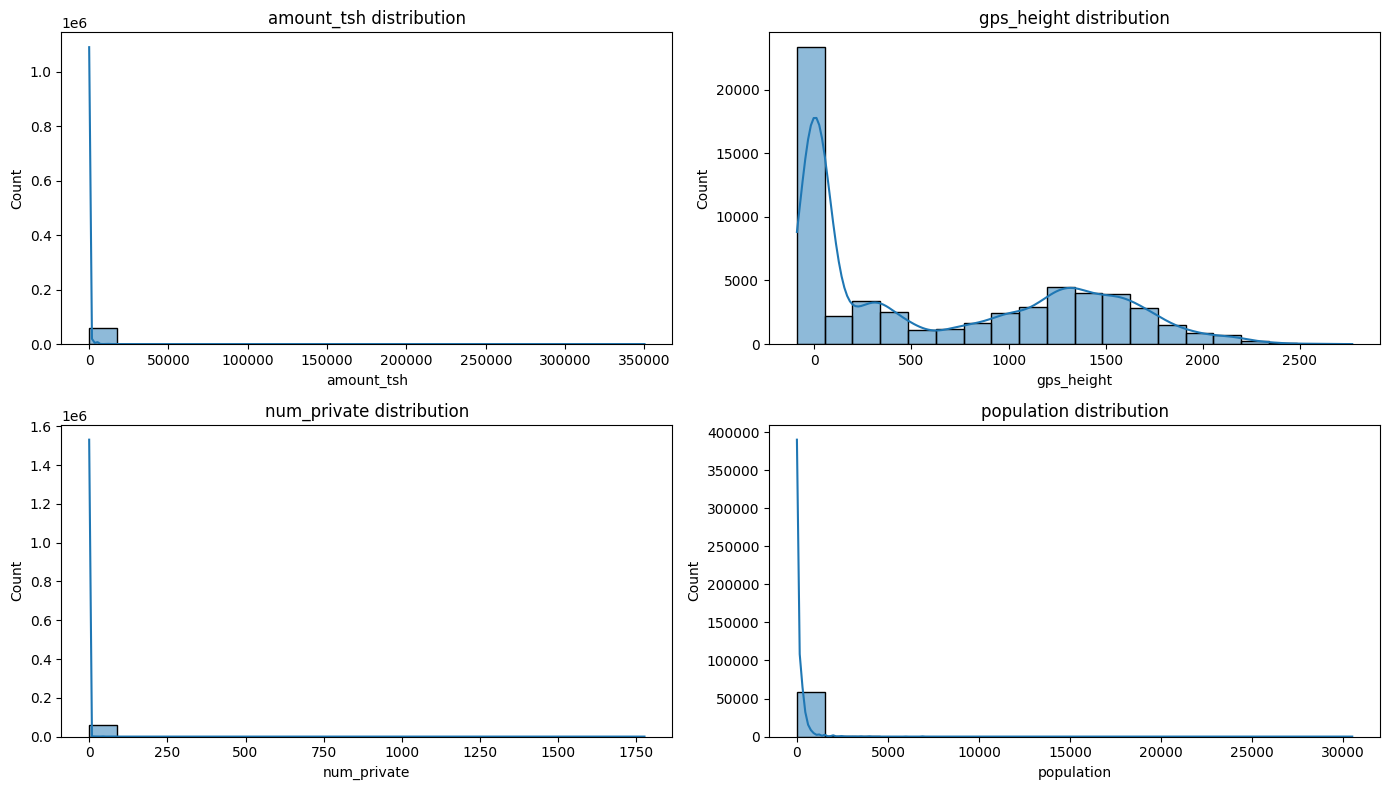

In [47]:
fig, axes = plt.subplots(2,2, figsize=(14,8))
sns.histplot(data=X, x='amount_tsh', kde=True, bins=20, ax=axes[0][0])
axes[0][0].set_title('amount_tsh distribution')
sns.histplot(data=X, x='gps_height', kde=True, bins=20, ax=axes[0][1])
axes[0][1].set_title('gps_height distribution')
sns.histplot(data=X, x='num_private', kde=True, bins=20, ax=axes[1][0])
axes[1][0].set_title('num_private distribution')
sns.histplot(data=X, x='population', kde=True, bins=20, ax=axes[1][1])
axes[1][1].set_title('population distribution')
plt.tight_layout()
plt.show()

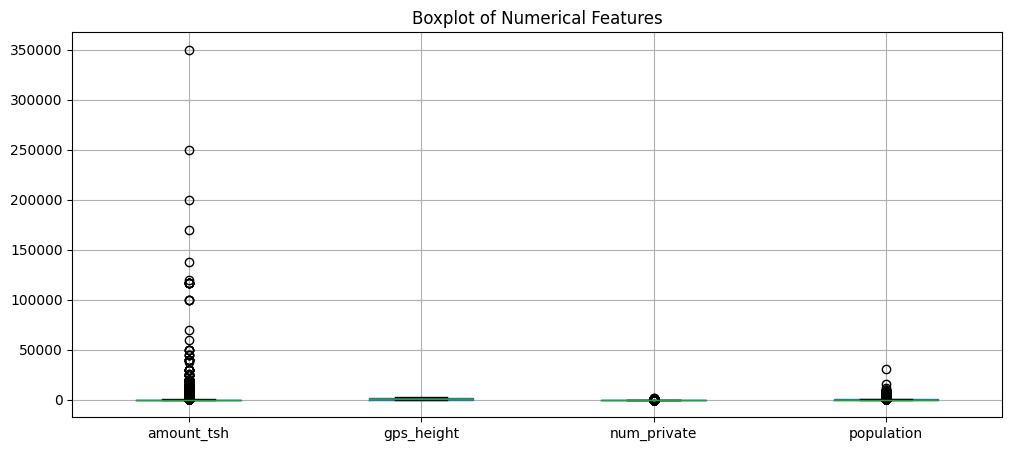

In [50]:
num_features = ['amount_tsh','gps_height','num_private','population']
plt.figure(figsize=(12, 5))
df[num_features].boxplot()
plt.title("Boxplot of Numerical Features")
plt.show()

In [22]:
other_df = X.loc[: ,['longitude','latitude','date_recorded']]
other_df.head(3)

,longitude,latitude,date_recorded
0,33.125828,-5.118154,2012-11-13
1,34.770717,-9.395642,2011-03-05
2,36.115056,-6.279268,2011-03-27


In [23]:
X = X.drop(['longitude','latitude','date_recorded'], axis=1)
X.columns

Index(['amount_tsh', 'gps_height', 'installer', 'wpt_name', 'num_private',
       'population', 'public_meeting', 'recorded_by', 'scheme_management',
       'permit', 'extraction_type', 'extraction_type_class', 'management',
       'management_group', 'payment_type', 'water_quality', 'quantity',
       'source', 'source_class', 'waterpoint_type', 'basin_name'],
      dtype='object')

In [27]:
X = X.drop('extraction_type', axis=1)

In [29]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [30]:
cat_cols = []
num_cols = []
for cols in X.columns:
    if X[cols].dtypes == "object":
        cat_cols.append(cols)
    else:
        num_cols.append(cols)

print("cat cols = \n", cat_cols)
print("num_cols = \n", num_cols)

cat cols = 
 ['installer', 'wpt_name', 'public_meeting', 'recorded_by', 'scheme_management', 'permit', 'extraction_type_class', 'management', 'management_group', 'payment_type', 'water_quality', 'quantity', 'source', 'source_class', 'waterpoint_type', 'basin_name']
num_cols = 
 ['amount_tsh', 'gps_height', 'num_private', 'population']


In [31]:
num_df = X.loc[:, num_cols]
print(num_df.head(3))

   amount_tsh  gps_height  num_private  population
0         0.0           0            0           0
1         0.0        1978            0          20
2         0.0           0            0           0


In [39]:
cat_df = X.loc[:, cat_cols]
print(cat_df.head(3))

  installer wpt_name public_meeting              recorded_by  \
0     TASAF  Mratibu            NaN  GeoData Consultants Ltd   
1     SHIPO     none           True  GeoData Consultants Ltd   
2      LVIA  Bombani           True  GeoData Consultants Ltd   

  scheme_management permit extraction_type_class management management_group  \
0               VWC   True              handpump        vwc       user-group   
1               NaN  False             rope pump        vwc       user-group   
2               VWC   True             motorpump        vwc       user-group   

  payment_type water_quality      quantity        source source_class  \
0      unknown         milky        enough  shallow well  groundwater   
1    never pay          soft        enough  shallow well  groundwater   
2   per bucket          soft  insufficient   machine dbh  groundwater   

               waterpoint_type       basin_name  
0                    hand pump  Lake Tanganyika  
1                    hand pum

In [43]:
print("before")
cat_df['management_group'].unique()
cat_df['management_group'] = cat_df['management_group'].str.replace('-',' ')
print('after replacement: ')
cat_df['management_group'].unique()

before
after replacement: 


array(['user group', 'commercial', 'other', 'unknown', 'parastatal'],
      dtype=object)

In [45]:
imputer = SimpleImputer(strategy="most_frequent")
imputed_cat_df = pd.DataFrame(imputer.fit_transform(cat_df), columns=cat_df.columns)

In [47]:
print("null values after simple imputer applied: ")
imputed_cat_df.isnull().sum()

null values after simple imputer applied: 


installer                0
wpt_name                 0
public_meeting           0
recorded_by              0
scheme_management        0
permit                   0
extraction_type_class    0
management               0
management_group         0
payment_type             0
water_quality            0
quantity                 0
source                   0
source_class             0
waterpoint_type          0
basin_name               0
dtype: int64

In [53]:
len(cat_cols)

16

In [54]:
for val in cat_df.columns:
    print(cat_df[val].unique())   

['TASAF' 'SHIPO' 'LVIA' ... 'BRA' 'Ardhi Water Wells' 'Said Omari']
['Mratibu' 'none' 'Bombani' ... 'Kwa Lugendo' 'Kwa Mvulula'
 'Kwa Wambura Msege']
[nan True False]
['GeoData Consultants Ltd']
['VWC' nan 'Water Board' 'Private operator' 'WUA' 'Water authority' 'WUG'
 'Other' 'Company' 'Parastatal' 'SWC' 'Trust']
[True False nan]
['handpump' 'rope pump' 'motorpump' 'gravity' 'submersible' 'other'
 'wind-powered']
['vwc' 'water board' 'private operator' 'wua' 'wug' 'company'
 'water authority' 'other' 'unknown' 'parastatal' 'trust' 'other - school']
['user group' 'commercial' 'other' 'unknown' 'parastatal']
['unknown' 'never pay' 'per bucket' 'on failure' 'monthly' 'annually'
 'other']
['milky' 'soft' 'salty' 'salty abandoned' 'coloured' 'unknown' 'fluoride'
 'fluoride abandoned']
['enough' 'insufficient' 'dry' 'seasonal' 'unknown']
['shallow well' 'machine dbh' 'spring' 'rainwater harvesting' 'river'
 'lake' 'other' 'dam' 'hand dtw' 'unknown']
['groundwater' 'surface' 'unknown']
['han

In [62]:
# applying encoding to categorical data
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
cat_df_encoded = pd.DataFrame(encoder.fit_transform(imputed_cat_df[cat_cols]), columns=encoder.get_feature_names_out(cat_cols))

ValueError: Shape of passed values is (59400, 1), indices imply (59400, 39633)

In [59]:
cat_encoded.shape

(1, 16)

In [32]:
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('cat', cat_transformer, cat_cols),
    ('num', num_transformer, num_cols)],
    remainder="passthrough"
)

In [34]:
X_transformed = preprocessor.fit_transform(X)

In [37]:
X_transformed.shape

(59400, 39637)